# 3.10: Lab: Support Vector Machine

## Simple Classification of the Iris Dataset

1. Import the necessary packages

In [1]:
import numpy as np
from sklearn import datasets
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC

2. Load the data and select just the petal length and width values as attributes and iris-virginia as the target (convert boolean to floating point)

In [2]:
iris = datasets.load_iris()

In [3]:
X = iris["data"][:,(2,3)]   # petal length, petal width
y = (iris["target"] == 2).astype(np.float64)   # Iris-Virginica

3. Scale the data

In [4]:
std_scaler = StandardScaler()
X_scaled = std_scaler.fit_transform(X)

4. Create and fit the classifier to the scaled data

In [5]:
svm_clf = LinearSVC(C=1, loss="hinge", random_state=13)
svm_clf.fit(X_scaled, y)

,"penalty penalty: {'l1', 'l2'}, default='l2'Specifies the norm used in the penalization. The 'l2'penalty is the standard used in SVC. The 'l1' leads to ``coef_``vectors that are sparse.",'l2'
,"loss loss: {'hinge', 'squared_hinge'}, default='squared_hinge'Specifies the loss function. 'hinge' is the standard SVM loss(used e.g. by the SVC class) while 'squared_hinge' is thesquare of the hinge loss. The combination of ``penalty='l1'``and ``loss='hinge'`` is not supported.",'hinge'
,"dual dual: ""auto"" or bool, default=""auto""Select the algorithm to either solve the dual or primaloptimization problem. Prefer dual=False when n_samples > n_features.`dual=""auto""` will choose the value of the parameter automatically,based on the values of `n_samples`, `n_features`, `loss`, `multi_class`and `penalty`. If `n_samples` < `n_features` and optimizer supportschosen `loss`, `multi_class` and `penalty`, then dual will be set to True,otherwise it will be set to False... versionchanged:: 1.3 The `""auto""` option is added in version 1.3 and will be the default in version 1.5.",'auto'
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.For an intuitive visualization of the effects of scalingthe regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1
,"multi_class multi_class: {'ovr', 'crammer_singer'}, default='ovr'Determines the multi-class strategy if `y` contains more thantwo classes.``""ovr""`` trains n_classes one-vs-rest classifiers, while``""crammer_singer""`` optimizes a joint objective over all classes.While `crammer_singer` is interesting from a theoretical perspectiveas it is consistent, it is seldom used in practice as it rarely leadsto better accuracy and is more expensive to compute.If ``""crammer_singer""`` is chosen, the options loss, penalty and dualwill be ignored.",'ovr'
,"fit_intercept fit_intercept: bool, default=TrueWhether or not to fit an intercept. If set to True, the feature vectoris extended to include an intercept term: `[x_1, ..., x_n, 1]`, where1 corresponds to the intercept. If set to False, no intercept will beused in calculations (i.e. data is expected to be already centered).",True
,"intercept_scaling intercept_scaling: float, default=1.0When `fit_intercept` is True, the instance vector x becomes ``[x_1,..., x_n, intercept_scaling]``, i.e. a ""synthetic"" feature with aconstant value equal to `intercept_scaling` is appended to the instancevector. The intercept becomes intercept_scaling * synthetic featureweight. Note that liblinear internally penalizes the intercept,treating it like any other term in the feature vector. To reduce theimpact of the regularization on the intercept, the `intercept_scaling`parameter can be set to a value greater than 1; the higher the value of`intercept_scaling`, the lower the impact of regularization on it.Then, the weights become `[w_x_1, ..., w_x_n,w_intercept*intercept_scaling]`, where `w_x_1, ..., w_x_n` representthe feature weights and the intercept weight is scaled by`intercept_scaling`. This scaling allows the intercept term to have adifferent regularization behavior compared to the other features.",1
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to ``class_weight[i]*C`` forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: int, default=0Enable verbose output. Note that this setting takes advantage of aper-process runtime setting in liblinear that, if enabled, may not workproperly in a multithreaded context.",0
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo random number 

5.       If you wish to make predictions on individual instances then you need to use the use reshape on the instance as in the example below:

Why do you need to do this? What does reshape do? And why is the second parameter -1?

In [6]:
svm_clf.predict(X_scaled[13].reshape(1,-1))

array([0.])

Reshape needs to be done as model is expecting 2D array. The model can't tell if it's a single sampel with 2 features, or two different samples with one feature. The correct structure makes it possible to predict off the correct structure.

6. How well does SVM perform? Call the predict function on the entire X_scaled data and examine its performance by examining the confusion matrix.

In [7]:
svm_predicts = svm_clf.predict(X_scaled)

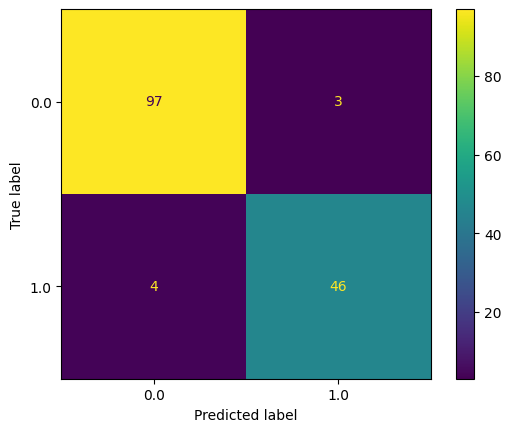

In [8]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
ConfusionMatrixDisplay.from_predictions(y, svm_predicts)
plt.show()

## Looking at the full iris dataset

1. Rather than looking at a subset of the iris data use the full dataset but don't split it into a test and training set (we're just going to focus on trying to build a good classifier). Keep working with a binary target variable (which aims to distinguish between iris-virginica and the other two categories).

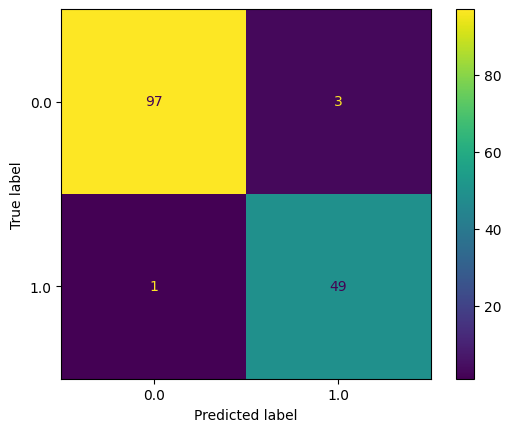

In [9]:
# Load and scale data
X_full = iris["data"]
X_full_scaled = std_scaler.fit_transform(X_full)

# Fit model
svm_clf.fit(X_full_scaled, y)

# Predict all and confusion matrix
svm_full_predicts = svm_clf.predict(X_full_scaled)
ConfusionMatrixDisplay.from_predictions(y, svm_full_predicts)
plt.show()


It performs better but still not perfect

## Classifying non-linear data using polynomial features

1. Add in polynomial features to the iris dataset and examine the performance again.

In [10]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.datasets import make_moons

In [11]:
# Add in a 3rd degree polynomial set of features
poly_features = PolynomialFeatures(degree=3, include_bias=False)
X_full_poly = poly_features.fit_transform(X_full)

# Scale the data
X_full_poly_scaled = std_scaler.fit_transform(X_full_poly)

In [12]:
# Create a svm classifier and fit the data
poly_svm_clf = LinearSVC(C=10, loss="hinge", random_state=42)
poly_svm_clf.fit(X_full_poly_scaled, y)

,"penalty penalty: {'l1', 'l2'}, default='l2'Specifies the norm used in the penalization. The 'l2'penalty is the standard used in SVC. The 'l1' leads to ``coef_``vectors that are sparse.",'l2'
,"loss loss: {'hinge', 'squared_hinge'}, default='squared_hinge'Specifies the loss function. 'hinge' is the standard SVM loss(used e.g. by the SVC class) while 'squared_hinge' is thesquare of the hinge loss. The combination of ``penalty='l1'``and ``loss='hinge'`` is not supported.",'hinge'
,"dual dual: ""auto"" or bool, default=""auto""Select the algorithm to either solve the dual or primaloptimization problem. Prefer dual=False when n_samples > n_features.`dual=""auto""` will choose the value of the parameter automatically,based on the values of `n_samples`, `n_features`, `loss`, `multi_class`and `penalty`. If `n_samples` < `n_features` and optimizer supportschosen `loss`, `multi_class` and `penalty`, then dual will be set to True,otherwise it will be set to False... versionchanged:: 1.3 The `""auto""` option is added in version 1.3 and will be the default in version 1.5.",'auto'
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.For an intuitive visualization of the effects of scalingthe regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",10
,"multi_class multi_class: {'ovr', 'crammer_singer'}, default='ovr'Determines the multi-class strategy if `y` contains more thantwo classes.``""ovr""`` trains n_classes one-vs-rest classifiers, while``""crammer_singer""`` optimizes a joint objective over all classes.While `crammer_singer` is interesting from a theoretical perspectiveas it is consistent, it is seldom used in practice as it rarely leadsto better accuracy and is more expensive to compute.If ``""crammer_singer""`` is chosen, the options loss, penalty and dualwill be ignored.",'ovr'
,"fit_intercept fit_intercept: bool, default=TrueWhether or not to fit an intercept. If set to True, the feature vectoris extended to include an intercept term: `[x_1, ..., x_n, 1]`, where1 corresponds to the intercept. If set to False, no intercept will beused in calculations (i.e. data is expected to be already centered).",True
,"intercept_scaling intercept_scaling: float, default=1.0When `fit_intercept` is True, the instance vector x becomes ``[x_1,..., x_n, intercept_scaling]``, i.e. a ""synthetic"" feature with aconstant value equal to `intercept_scaling` is appended to the instancevector. The intercept becomes intercept_scaling * synthetic featureweight. Note that liblinear internally penalizes the intercept,treating it like any other term in the feature vector. To reduce theimpact of the regularization on the intercept, the `intercept_scaling`parameter can be set to a value greater than 1; the higher the value of`intercept_scaling`, the lower the impact of regularization on it.Then, the weights become `[w_x_1, ..., w_x_n,w_intercept*intercept_scaling]`, where `w_x_1, ..., w_x_n` representthe feature weights and the intercept weight is scaled by`intercept_scaling`. This scaling allows the intercept term to have adifferent regularization behavior compared to the other features.",1
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to ``class_weight[i]*C`` forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: int, default=0Enable verbose output. Note that this setting takes advantage of aper-process runtime setting in liblinear that, if enabled, may not workproperly in a multithreaded context.",0
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo random number

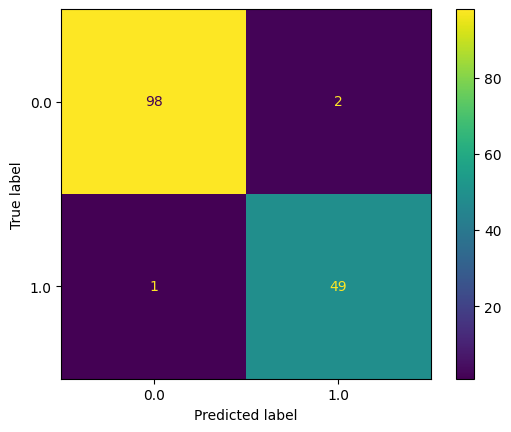

In [13]:
# Predict all and confusion matrix
poly_svm_full_predicts = poly_svm_clf.predict(X_full_poly_scaled)
ConfusionMatrixDisplay.from_predictions(y, poly_svm_full_predicts)
plt.show()


Improved, but not perfect.

## Using a polynomial kernal

Try using a polynomial kernel to solve build the classifier. Again, examine the performance. Look at the impact of different parameter settings.

In [14]:
from sklearn.svm import SVC

In [15]:
poly_k_svm_clf = SVC(kernel="poly", degree=3, coef0=10, C=10)
poly_k_svm_clf.fit(X_full_poly_scaled, y)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",10
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'poly'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",10
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


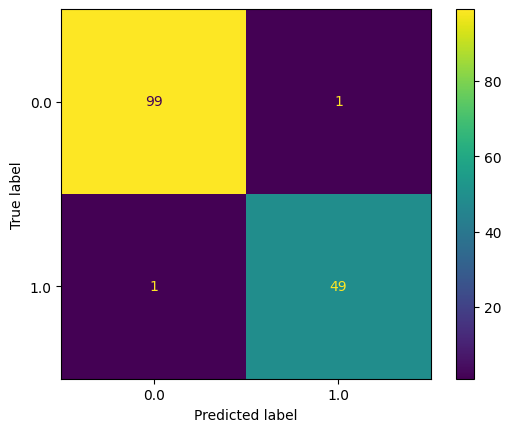

In [16]:
# Predict all and confusion matrix
poly_k_svm_full_predicts = poly_k_svm_clf.predict(X_full_poly_scaled)
ConfusionMatrixDisplay.from_predictions(y, poly_k_svm_full_predicts)
plt.show()

## Using a Radial Basis Function (RBF) kernal

1. This time create a classifier with a RBF kernel and fit this to the data and examine its performance. What impact do the parameter settings have?

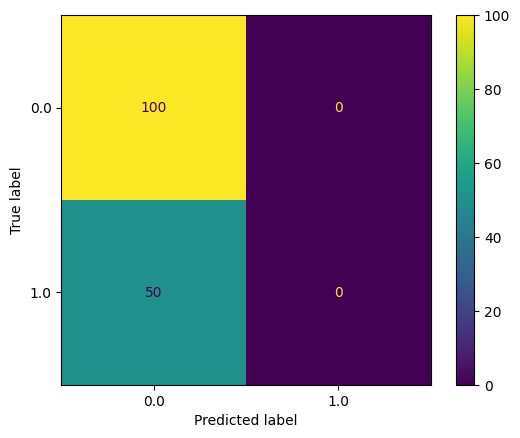

In [17]:
rbf_svm_clf = SVC(kernel="rbf", gamma=5, C=0.0001)
rbf_svm_clf.fit(X_full_poly_scaled, y)

# Predict all and confusion matrix
rbf_full_predicts = rbf_svm_clf.predict(X_full_poly_scaled)
ConfusionMatrixDisplay.from_predictions(y, rbf_full_predicts)
plt.show()

## Multi-Class Classification sing SVMs

Load the Wine dataset, split it into training and test sets, scale the features, train a multi-class SVM classifier, and examine performance using accuracy, classification report, and a confusion matrix.

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

In [19]:
wine = datasets.load_wine()

X_wine = wine["data"]
y_wine = wine["target"]

print(wine["DESCR"][:1000])
print("Feature names:", wine["feature_names"])
print("Target names:", wine["target_names"])

.. _wine_dataset:

Wine recognition dataset
------------------------

**Data Set Characteristics:**

:Number of Instances: 178
:Number of Attributes: 13 numeric, predictive attributes and the class
:Attribute Information:
    - Alcohol
    - Malic acid
    - Ash
    - Alcalinity of ash
    - Magnesium
    - Total phenols
    - Flavanoids
    - Nonflavanoid phenols
    - Proanthocyanins
    - Color intensity
    - Hue
    - OD280/OD315 of diluted wines
    - Proline
    - class:
        - class_0
        - class_1
        - class_2

:Summary Statistics:

============================= ==== ===== ======= =====
                                Min   Max   Mean     SD
============================= ==== ===== ======= =====
Alcohol:                      11.0  14.8    13.0   0.8
Malic Acid:                   0.74  5.80    2.34  1.12
Ash:                          1.36  3.23    2.36  0.27
Alcalinity of Ash:            10.6  30.0    19.5   3.3
Magnesium:                    70.0 162.0    99.7  14.3

In [20]:
X_wine_train, X_wine_test, y_wine_train, y_wine_test = train_test_split(
    X_wine,
    y_wine,
    test_size=0.25,
    random_state=13,
    stratify=y_wine
)

In [21]:
wine_scaler = StandardScaler()

X_wine_train_scaled = wine_scaler.fit_transform(X_wine_train)
X_wine_test_scaled = wine_scaler.transform(X_wine_test)

In [22]:
wine_svm_clf = SVC(kernel="rbf", C=1, gamma="scale", random_state=13)

wine_svm_clf.fit(X_wine_train_scaled, y_wine_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [23]:
wine_train_predicts = wine_svm_clf.predict(X_wine_train_scaled)
wine_test_predicts = wine_svm_clf.predict(X_wine_test_scaled)

print("Training accuracy:", accuracy_score(y_wine_train, wine_train_predicts))
print("Test accuracy:", accuracy_score(y_wine_test, wine_test_predicts))

Training accuracy: 1.0
Test accuracy: 1.0


In [24]:
print(classification_report(
    y_wine_test,
    wine_test_predicts,
    target_names=wine["target_names"]
))

              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        15
     class_1       1.00      1.00      1.00        18
     class_2       1.00      1.00      1.00        12

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



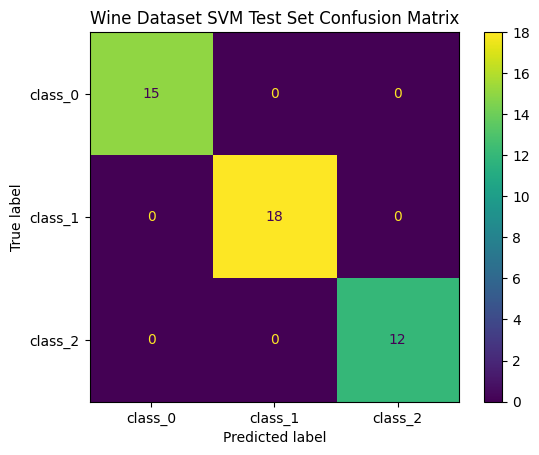

In [25]:
ConfusionMatrixDisplay.from_predictions(
    y_wine_test,
    wine_test_predicts,
    display_labels=wine["target_names"]
)

plt.title("Wine Dataset SVM Test Set Confusion Matrix")
plt.show()

In [26]:
wine_linear_svm_clf = LinearSVC(C=1, random_state=42, max_iter=10000)

wine_linear_svm_clf.fit(X_wine_train_scaled, y_wine_train)

wine_linear_test_predicts = wine_linear_svm_clf.predict(X_wine_test_scaled)

print("Linear SVM test accuracy:", accuracy_score(y_wine_test, wine_linear_test_predicts))
print(classification_report(
    y_wine_test,
    wine_linear_test_predicts,
    target_names=wine["target_names"]
))

Linear SVM test accuracy: 1.0
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        15
     class_1       1.00      1.00      1.00        18
     class_2       1.00      1.00      1.00        12

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



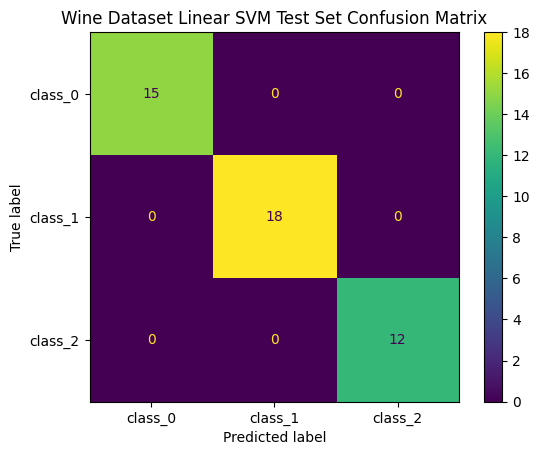

In [27]:
ConfusionMatrixDisplay.from_predictions(
    y_wine_test,
    wine_linear_test_predicts,
    display_labels=wine["target_names"]
)

plt.title("Wine Dataset Linear SVM Test Set Confusion Matrix")
plt.show()
